# Feature Explanation User Study — design from the UI export

Same workflow as `feature_explanation_user_study.ipynb`, with one difference: the
experiment design is not typed into this notebook. `xaikitTest` is handed the
experiment-design UI export and reads every IV, CV, DV and the study protocol
from it.

`apparatus` in the export is intentionally ignored — it configures the
participant-facing UI, which this API never renders.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'api.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.api import xaikitTest

SEED = 42
BASELINE_MODEL = 'knn'  # knn, decision_tree, logistic_regression, or mlp
DESIGN_EXPORT = repo_root / 'tutorials' / 'experiment-design.json'
OUTPUT_DIR = Path(os.environ.get(
    'XAIKIT_TUTORIAL_OUTPUT_DIR',
    repo_root / 'tutorials' / 'feature_explanation_design_export_output',
))

## 1. Load the design into the study

`design=` takes the export's path directly — a loaded dict or a `DesignExport`
work identically. It normalizes the questionnaire-shaped export into the names the
planner uses (levels split out of their single string, `"Tested with XAI"` becomes
the boolean IV `tested_w_xai`, `"Input Gradients (paper)"` loses the
parenthetical) and registers the IVs, CVs, DVs and protocol in one step.

`study.design_export` is that normalized view. The table below is what the UI
actually said, next to the name each entry was given — read it before running
anything else.

`phase` stays part of the participant journey rather than an IV: every participant
receives training trials followed by testing trials.

In [2]:
study = xaikitTest(
    'feature_explanation_from_design_export',
    output_dir=OUTPUT_DIR,
    design=DESIGN_EXPORT,          # the UI export drives the whole design
)
design = study.design_export       # normalized view of what the UI exported

print(f'Study      : {design.study_title}')
print(f'Dataset    : {design.dataset_id}')
print(f'Framework  : {design.model_framework}   Design: {design.design_type}')
print(f'UI sample  : {design.participants_per_condition} per condition, '
      f'{design.total_participants} total, {design.trials_per_participant} trials each')
print()
display(pd.DataFrame(design.summary_rows()))
study.validate_design()

Study      : Wine Quality
Dataset    : wine_quality
Framework  : CoAX   Design: mixed
UI sample  : 25 per condition, 300 total, 10 trials each



,role,name,detail,levels,source_label
0,IV,xai_method,between,"lime, shap, integrated_gradients, input_gradients",XAI Method
1,IV,tested_w_xai,within,"True, False",Tested with XAI
2,IV,xai_type,between,"none, attribution, importance",XAI Type
3,DV,forward_accuracy,continuous,,forward_sim



IV configuration:
  xai_method           type=between  randomization=-     levels=['lime', 'shap', 'integrated_gradients', 'input_gradients']
  tested_w_xai         type=within   randomization=trial levels=[True, False]
  xai_type             type=between  randomization=-     levels=['none', 'attribution', 'importance']

CVs: []
DVs: ['forward_accuracy']


({'xai_method': {'type': 'between',
   'levels': ['lime', 'shap', 'integrated_gradients', 'input_gradients']},
  'tested_w_xai': {'type': 'within',
   'levels': [True, False],
   'randomization': 'trial'},
  'xai_type': {'type': 'between',
   'levels': ['none', 'attribution', 'importance']}},
 {},
 {'forward_accuracy': ['continuous']})

## 3. Train the AI, then sample balanced trials

The dataset id, participants per condition, and trials per participant all
come from the export. Only the training/testing split of those trials is set
here, because the export records a single total.


In [3]:
# Sample size and trial count come from the export, like everything else.
# The export gives a total trials-per-participant but no training/testing split,
# so that one split is stated here rather than guessed silently.
PARTICIPANTS_PER_CONDITION = design.participants_per_condition
NUM_TRAINING = 4
NUM_TESTING = design.trials_per_participant - NUM_TRAINING

print(f'Participants per between-condition : {PARTICIPANTS_PER_CONDITION}')
print(f'Trials per participant             : {design.trials_per_participant} '
      f'({NUM_TRAINING} training + {NUM_TESTING} testing)')

data = study.prepare_dataset(
    design.dataset_id,
    feature_cols=['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH'],
    rank_features_by_target=False,
    model_type='mlp',
    test_size=0.4,
    random_state=SEED,
)
study.train_AI_model(
    model_type='mlp',
    target_metric='accuracy',
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)
trial_result = study.generate_trials(
    participants_per_between_condition=PARTICIPANTS_PER_CONDITION,
    num_training=NUM_TRAINING,
    num_testing=NUM_TESTING,
    balance_by_ai_prediction=True,
    output_dir='trials',
    seed=SEED,
    preview_rows=4,
)
trials = pd.DataFrame(trial_result.trials)
print(f'Generated {len(trials):,} trial rows for '
      f"{trials['participantId'].nunique()} participants")
balance_audit = (
    trials.groupby(['participantId', 'phase', 'sampled_ai_prediction'])
    .size().rename('trials').reset_index()
    .groupby(['phase', 'sampled_ai_prediction'])['trials']
    .agg(['min', 'max']).reset_index()
)
display(study.training_summary_table(), balance_audit)

Participants per between-condition : 25
Trials per participant             : 10 (4 training + 6 testing)
Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH']
Encoding  : one-hot
Train set : 959 samples  (60%)
Test set  : 640 samples  (40%)
Class balance (train) -> class 0: 829
Class balance (train) -> class 1: 130
First test instanceIds: [1188, 902, 818, 38, 1255, 496, 947, 861, 839, 1559]
Counterbalancing strategy: complete_counterbalancing
Participant assignments: 300 total
Instance pool rows: 300
Trial rows: 3000
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-ap

,target_metric,target_score,final_score,epochs,batch_size,reached_target,target_accuracy,final_accuracy,model_type,dataset
0,accuracy,0.9,0.900938,420,100,True,0.9,0.900938,mlp,wine_quality


,phase,sampled_ai_prediction,min,max
0,testing,0,3,3
1,testing,1,3,3
2,training,0,2,2
3,training,1,2,2


## 4. Generate the prediction and explanation pool

The XAI methods are not listed here either — `study.explanations()` reads the
`xai_method` levels straight from the design that came out of the export.

Explanations are generated only for training trials and testing trials where XAI
is visible; AI predictions stay available internally for scoring.

In [4]:
explanation_path, explanation_pool = study.explanations(
    output_dir='generated_explanation',
    target=1,
    method_kwargs={'lime': {'num_samples': 1000}},
)
print(f'Explanation table: {explanation_path}')
display(explanation_pool['expMethod'].value_counts().rename('rows').to_frame())

Using stored XAI methods from the design: ['lime', 'shap', 'integrated_gradients', 'input_gradients']
Using stored model name for explanation files: 'mlp'
XAIKit validation: explanation_generation

Reminders:
  - user_task: Set `user_task` for cognitive simulation.
    Suggestion: Planner-only OK. Supported: counterfactual_simulation, forward_simulation.

Generating explanations for xai method: lime
  Sampled instances: 322
  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/generated_explanation/lime_mlp_wine_quality.csv shape=(322, 12)

Generating explanations for xai method: shap
  Sampled instances: 329


  0%|          | 0/329 [00:00<?, ?it/s]

  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/generated_explanation/shap_mlp_wine_quality.csv shape=(329, 12)

Generating explanations for xai method: integrated_gradients
  Sampled instances: 323
  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/generated_explanation/integrated_gradients_mlp_wine_quality.csv shape=(323, 12)

Generating explanations for xai method: input_gradients
  Sampled instances: 310
  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/generated_explanation/input_gradients_mlp_wine_quality.csv shape=(310, 12)

Saved complete AI prediction table: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/generated_explanation/predictions_mlp_wine_quality.csv shape=(1599, 5)

Combined explanation CSV: /Users/wangzhuoyulucas

/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


,rows
expMethod,
__prediction_only__,1599
shap,329
integrated_gradients,323
lime,322
input_gradients,310


## 5. Configure and preview the virtual participant

Training previews show AI feedback. Testing previews hide the AI prediction and
its box, whether or not the explanation is visible.

ipywidgets unavailable. Showing HTML Back/Next preview.



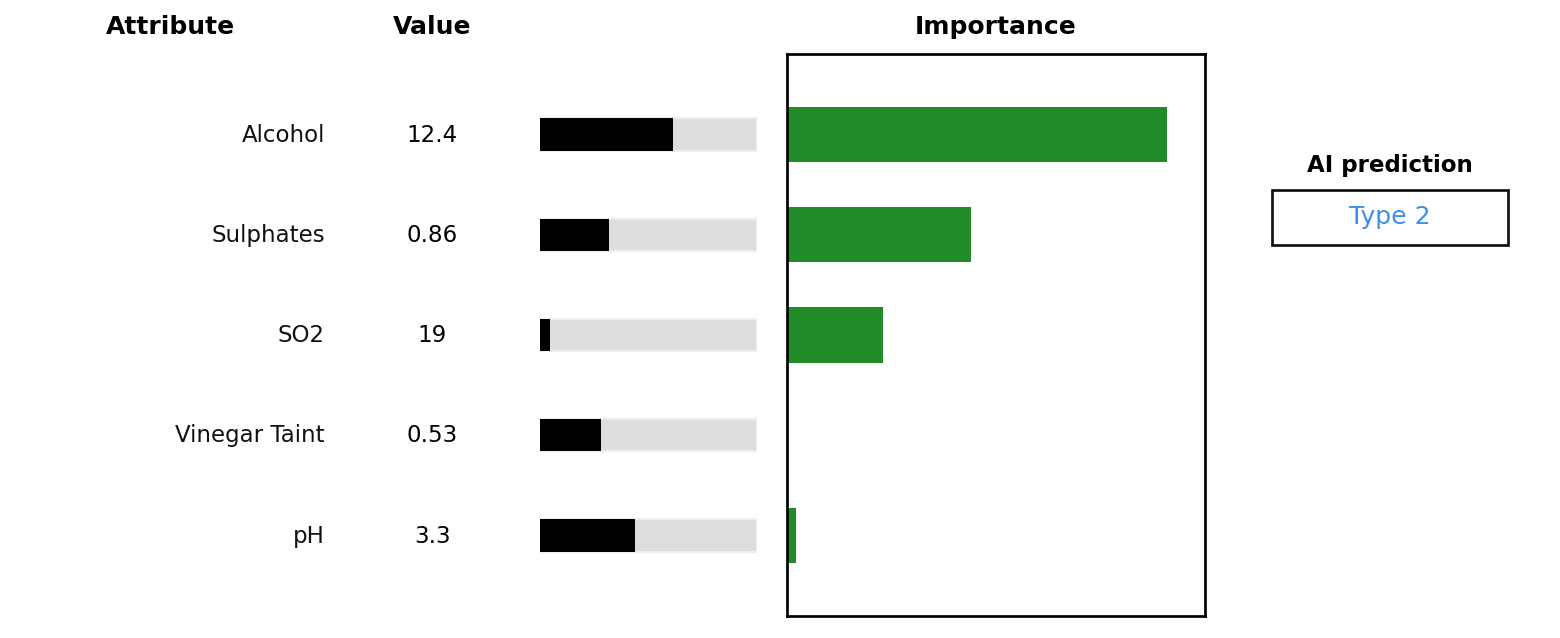
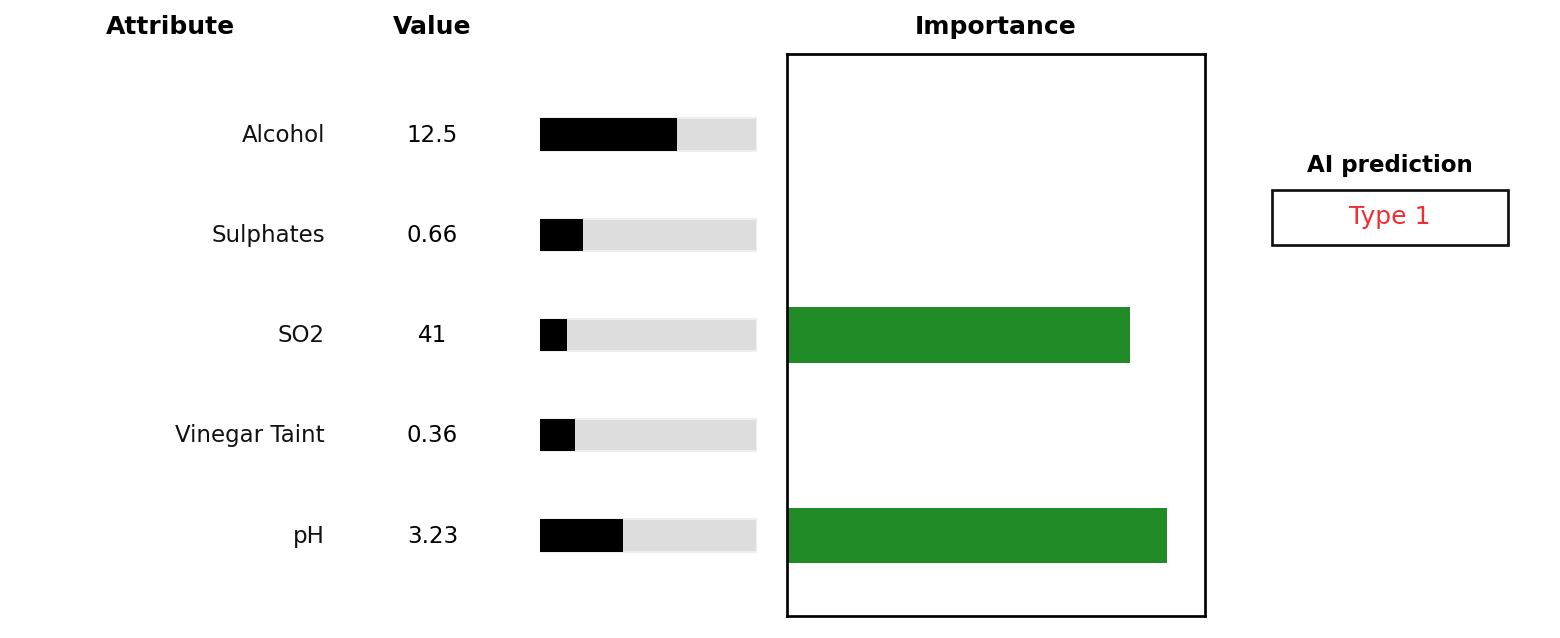
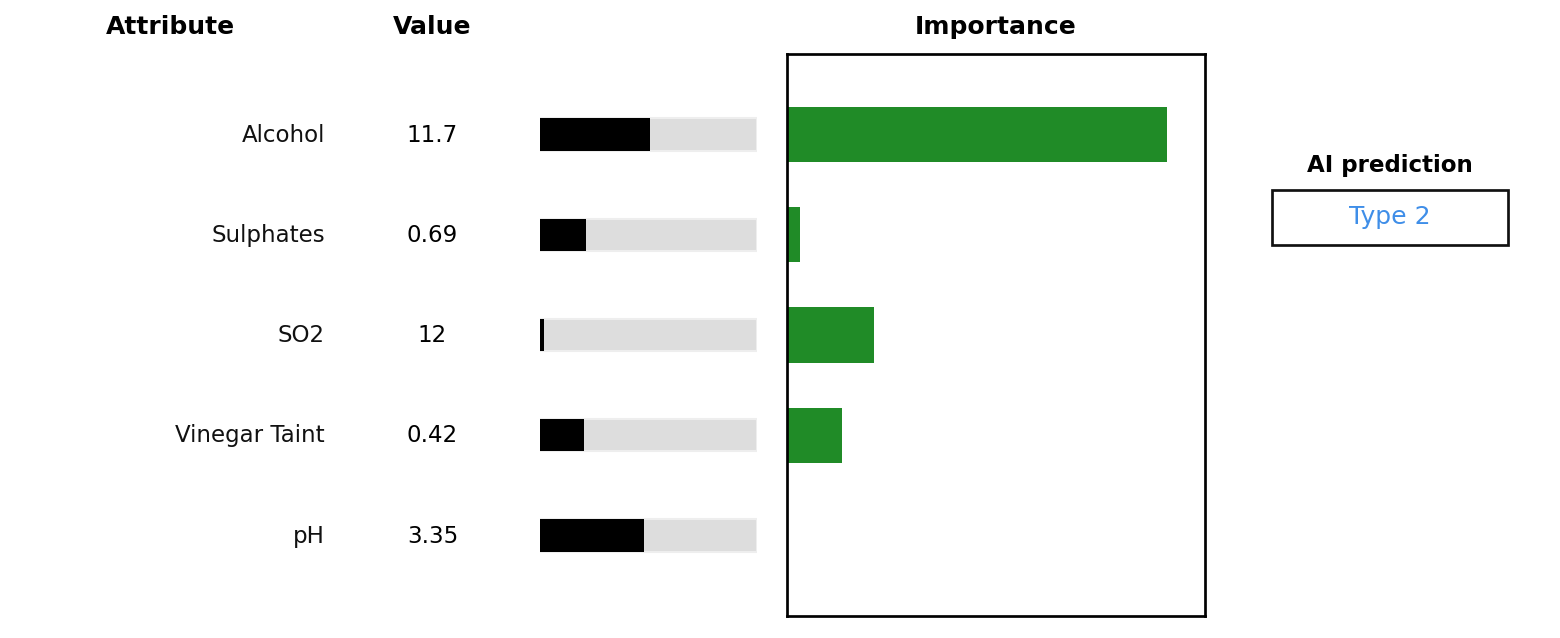
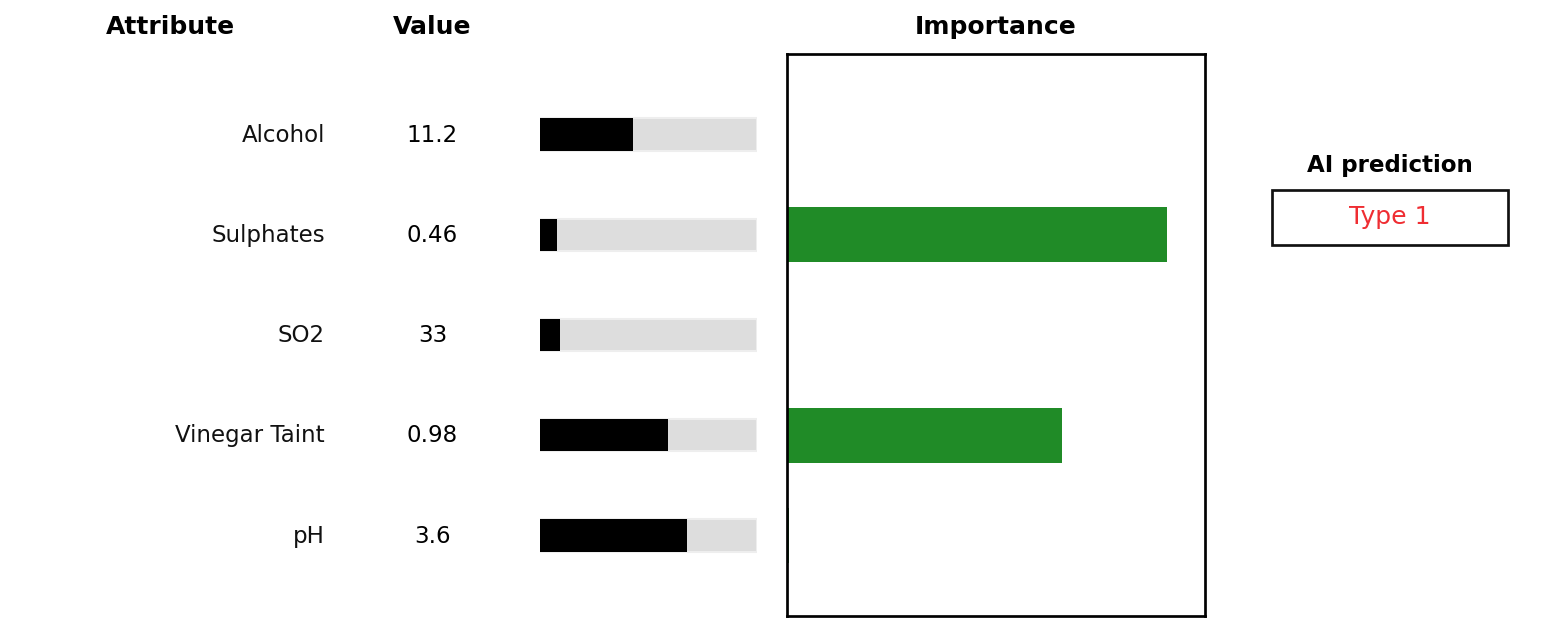
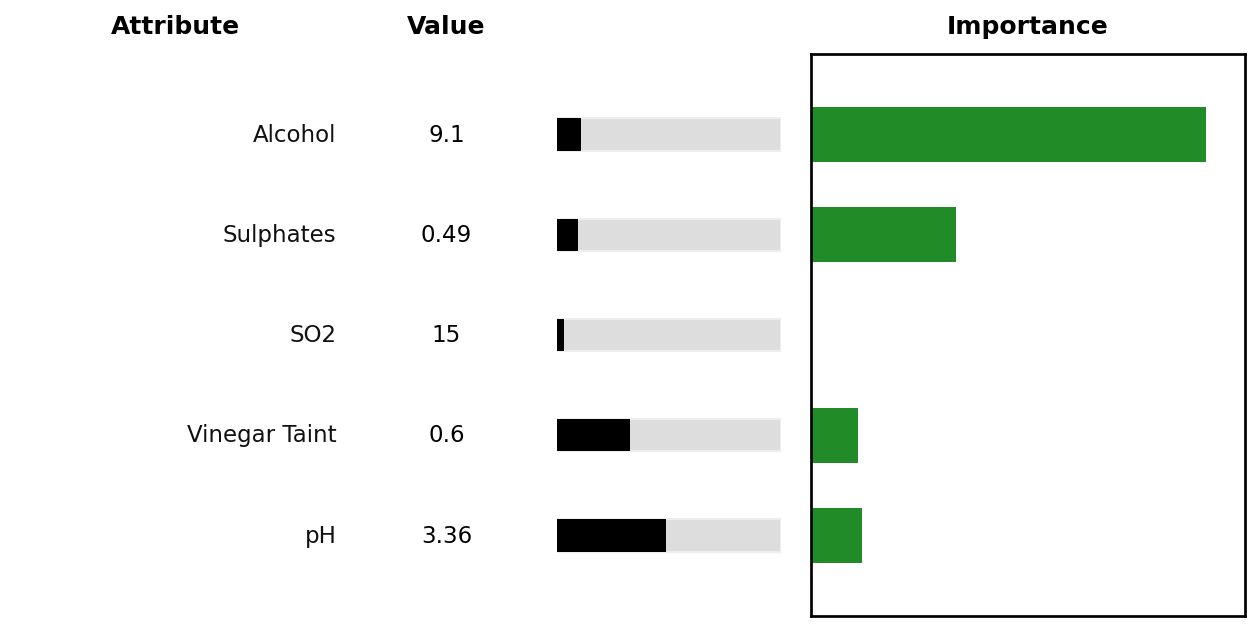
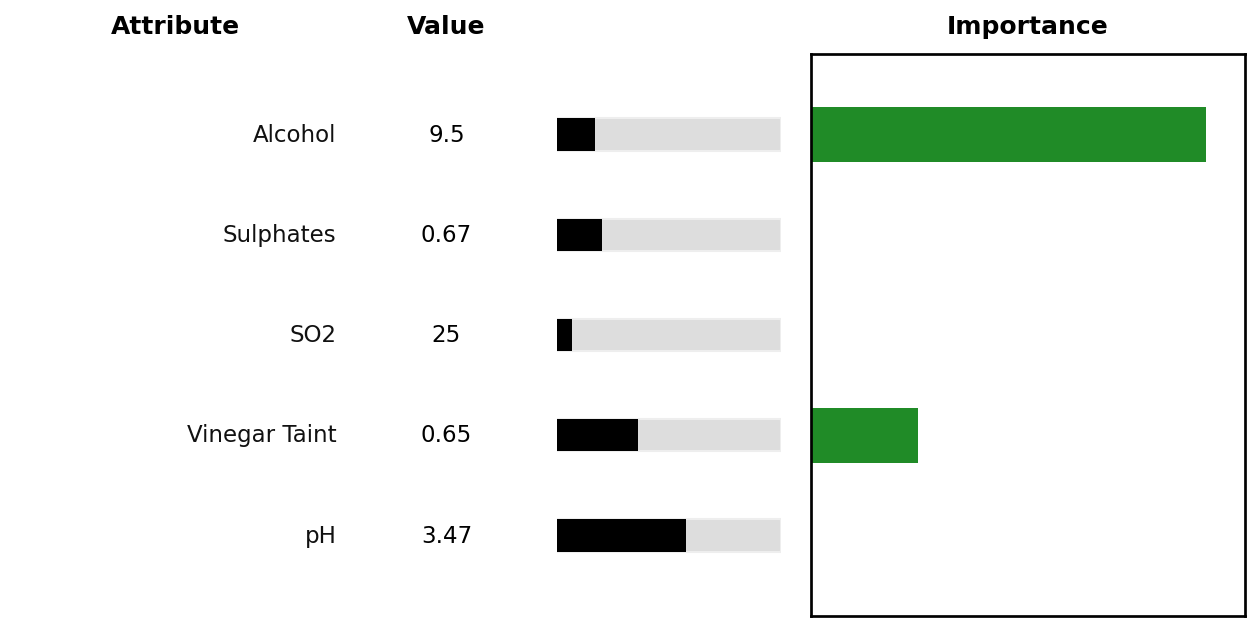
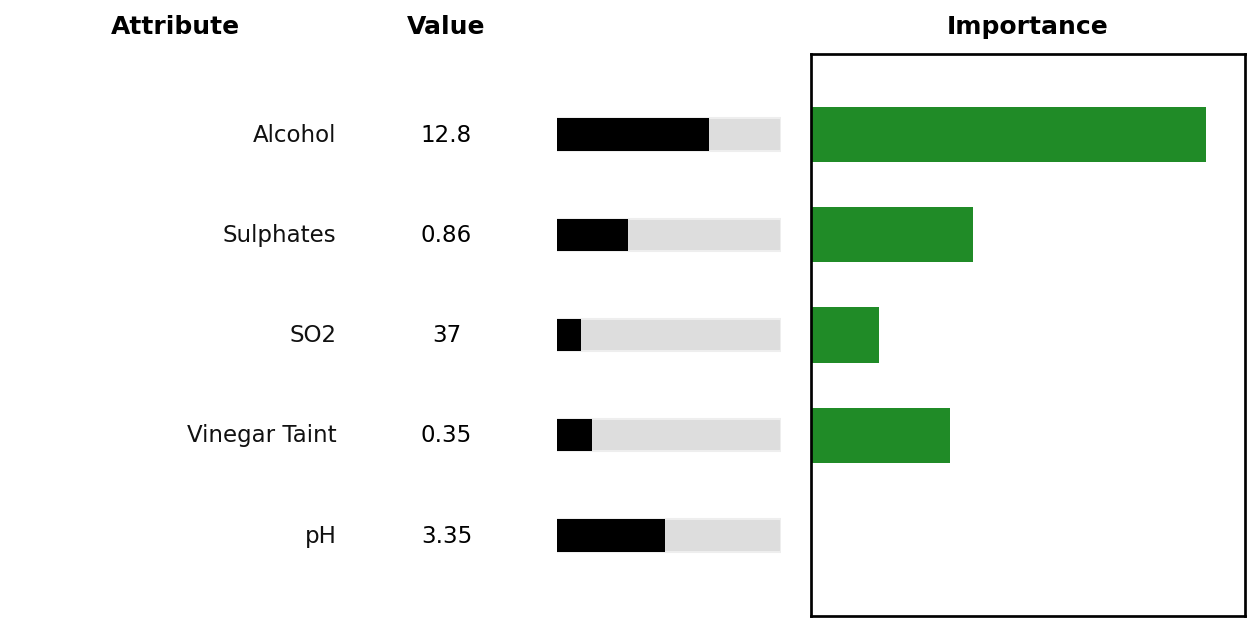

In [5]:
study.set_cognitive_model(
    cognitive_model_id=BASELINE_MODEL,
    model_kwargs={'n_neighbors': 3} if BASELINE_MODEL == 'knn' else {},
)
preview_id = int(trials['participantId'].iloc[0])
participant_trials = study.preview_participant_trials(
    participant_id=preview_id,
    visualization='importance',
    class_labels=['Type 1', 'Type 2'],
    fallback='html',
)

## 6. Run and analyze the virtual experiment

Only DVs the executor can produce are analysable. `design.simulatable_dvs` holds
those; any other measure the export listed was reported as a warning in step 1 and
has to come from human participants.

--- xai_method x forward_accuracy ---


,index,xai_method,count,mean,std,sem
0,0,input_gradients,75,0.566667,0.171112,0.019758
1,1,integrated_gradients,75,0.540000,0.179338,0.020708
2,2,lime,75,0.564444,0.183586,0.021199
3,3,shap,75,0.586667,0.192502,0.022228


--- xai_type x forward_accuracy ---


,index,xai_type,count,mean,std,sem
0,0,attribution,100,0.568333,0.180557,0.018056
1,1,importance,100,0.573333,0.191456,0.019146
2,2,none,100,0.551667,0.173585,0.017359


Saved 3,000 responses to /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/simulated_results/simulated_results.csv and /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_output/simulated_results/simulated_results.json


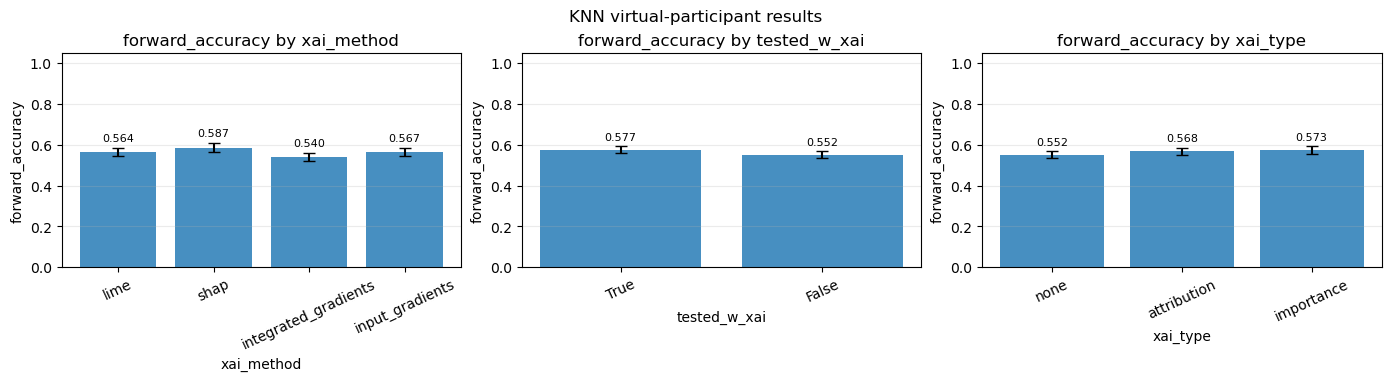

In [6]:
simulated_results = study.run_experiment(
    mode='whole_experiment',
    participant_id=None,
    explanation_pool=explanation_pool,
)
csv_path, json_path = study.save_results(out_dir='simulated_results')

between_ivs = [iv['name'] for iv in design.between_ivs]
for dv in design.simulatable_dvs:
    for iv in between_ivs:
        analysis = study.analyze_iv_dv(iv=iv, dv=dv)
        print(f'--- {iv} x {dv} ---')
        display(analysis.descriptives)

study.plot_results_grid(
    ivs=[iv['name'] for iv in design.ivs],
    dvs=design.simulatable_dvs,
    phase='testing',
    title=f'{BASELINE_MODEL.upper()} virtual-participant results',
)
print(f'Saved {len(simulated_results):,} responses to {csv_path} and {json_path}')

## Before a human study

Treat this output as a machine-proxy check, not evidence about people. The sample
size already matches the export; freeze stimuli and analysis rules, justify that
sample size, and obtain ethics approval where required.